## Cell 1: feature data load + train/test split setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_pickle('C:/Users/santh/battery-rul-project/data/processed/feature_battery_data.pkl')
df.head()

,battery,cycle_idx,capacity_Ah,SOH,RUL,v_mean,v_std,v_min,v_max,v_slope,v_range,i_mean,i_std,t_mean,t_max,t_min,t_rise,capacity_delta,v_mean_delta,t_rise_delta
0,B0005,1,1.856487,1.000000,589,3.529343,0.234954,2.618762,4.191492,-0.002526,1.572729,-1.822711,0.582457,32.578022,38.951894,24.327385,14.624508,0.000000,0.000000,0.000000
1,B0005,3,1.846327,0.994527,587,3.536819,0.233775,2.604616,4.189773,-0.002502,1.585157,-1.821613,0.583789,32.730829,39.003326,24.690054,14.313272,-0.010160,0.007476,-0.311236
2,B0005,5,1.835349,0.988614,585,3.543293,0.226301,2.700208,4.188187,-0.002433,1.487979,-1.820274,0.585058,32.648494,38.802209,24.734266,14.067943,-0.010978,0.006474,-0.245329
3,B0005,7,1.835263,0.988567,583,3.543247,0.231448,2.617717,4.188461,-0.002479,1.570744,-1.829303,0.572175,32.520265,38.725760,24.652950,14.072810,-0.000087,-0.000046,0.004867
4,B0005,9,1.834646,0.988235,581,3.541929,0.235356,2.574526,4.188299,-0.002512,1.613772,-1.829833,0.572161,32.387717,38.630248,24.520862,14.109386,-0.000617,-0.001319,0.036576


## Cell 2:  Deciding the target (Let's start with SOH prediction, RUL can be done later)

In [2]:
feature_cols = ['v_mean', 'v_std', 'v_min', 'v_max', 'v_slope', 'v_range',
                'i_mean', 'i_std', 't_mean', 't_max', 't_min', 't_rise',
                'capacity_delta', 'v_mean_delta', 't_rise_delta']

X = df[feature_cols]
y = df['SOH']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
print(X_train.shape, X_test.shape)

(508, 15) (128, 15)


## Cell 3: scaling (Linear/Ridge/Lasso/SVR need scaling)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Cell 4: 5 baseline models train + evaluate

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Polynomial Regression (deg=2)': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'SVR (RBF kernel)': SVR(kernel='rbf', C=1.0, epsilon=0.01),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,model,RMSE,MAE,R2
3,Polynomial Regression (deg=2),0.007801,0.005375,0.994575
0,Linear Regression,0.014265,0.010957,0.981859
1,Ridge Regression,0.014885,0.011624,0.980248
4,SVR (RBF kernel),0.016380,0.010524,0.976082
2,Lasso Regression,0.027543,0.020003,0.932372


## Cell 5: 5 models, individual subplot (Actual vs Predicted scatter)

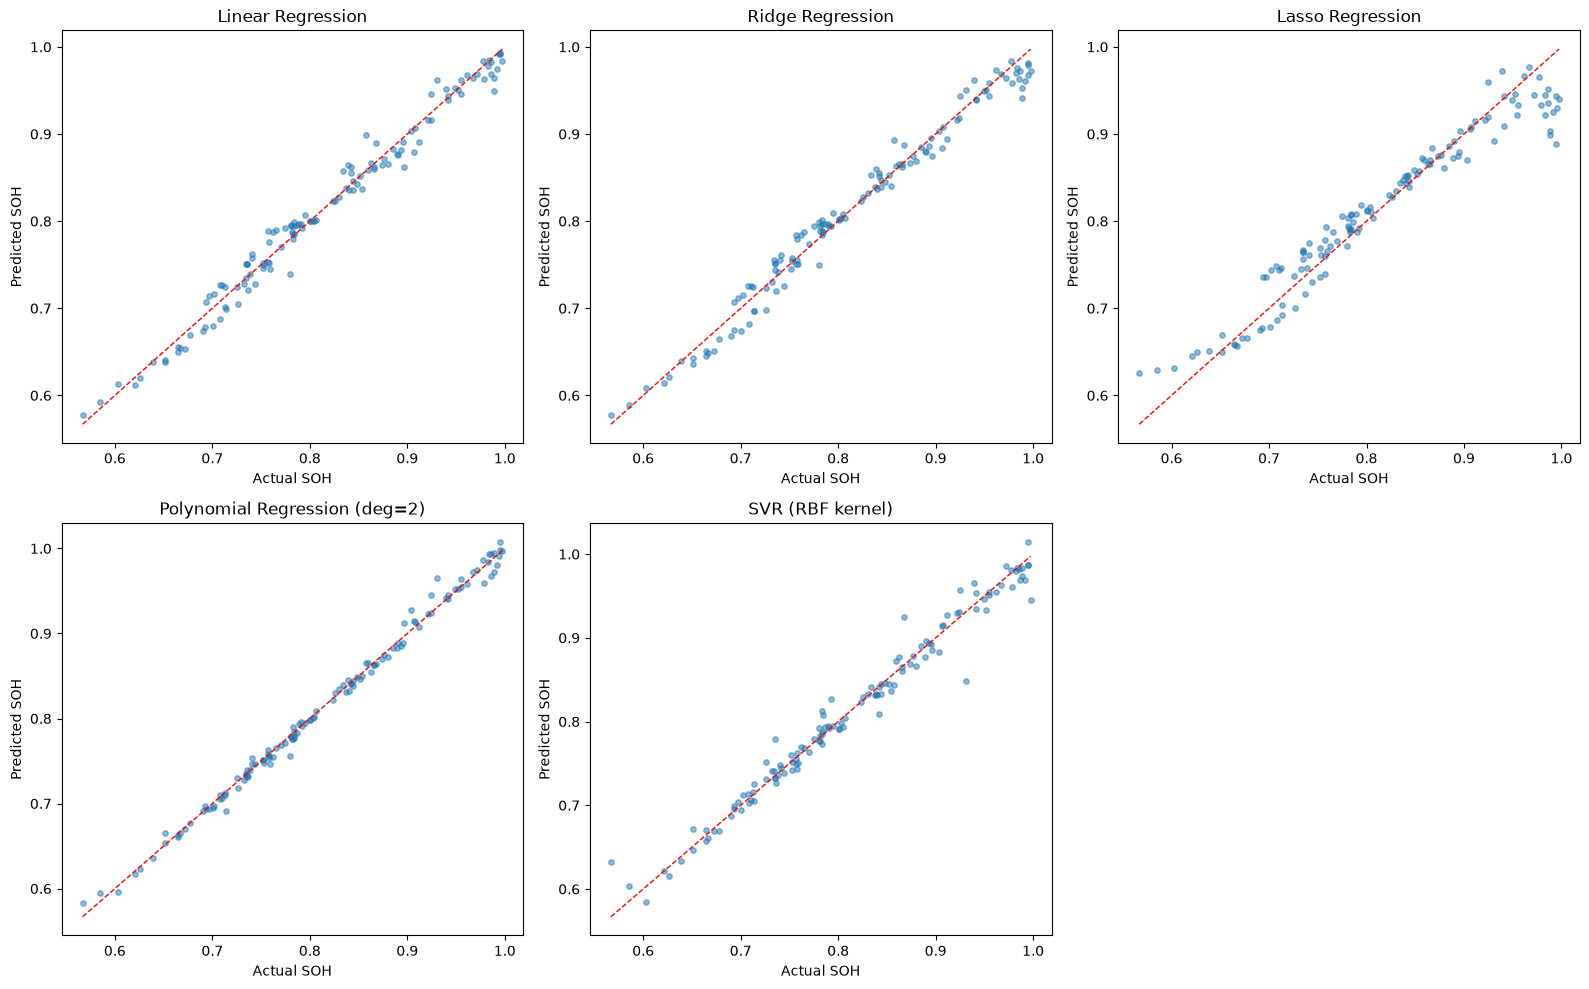

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test_scaled)

    ax = axes[idx]
    ax.scatter(y_test, preds, alpha=0.5, s=15)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_xlabel('Actual SOH')
    ax.set_ylabel('Predicted SOH')
    ax.set_title(name)

# 6th subplot will be empty (5 models, 6 slots) — hide it
axes[5].axis('off')

plt.tight_layout()
plt.show()

## Cell 6: visualize best model predictions 

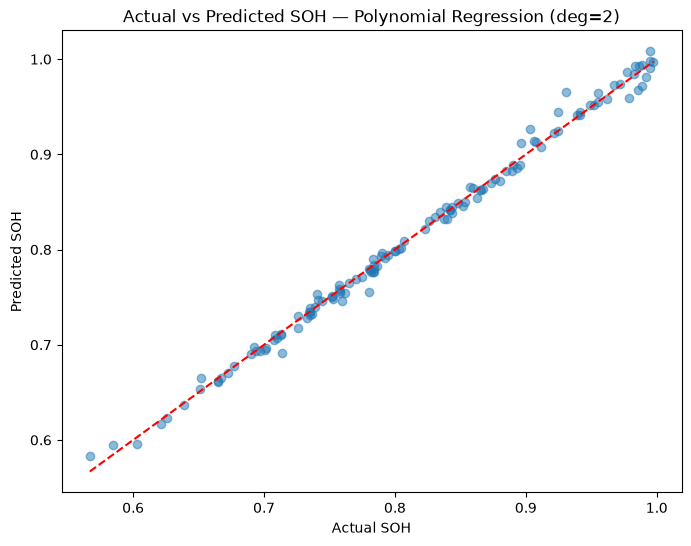

In [8]:
import matplotlib.pyplot as plt

best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.title(f'Actual vs Predicted SOH — {best_model_name}')
plt.show()

## Cell 7: save results 

In [10]:
import os
os.makedirs('C:/Users/santh/battery-rul-project/results', exist_ok=True)

results_df.to_csv('C:/Users/santh/battery-rul-project/results/baseline_model_results.csv', index=False)
print("Saved baseline results.")

Saved baseline results.
